# Module 08 Lab - The Bias-Variance Tradeoff**Objective:** To understand and visualize the concepts of **overfitting**, **underfitting**, and the **bias-variance tradeoff**, which are central to building models that generalize well to new data.**In this lab, you will train models of varying complexity and plot their performance to see these concepts in action.**

## Part 1: Understanding the Concepts*   **Underfitting (High Bias):** The model is **too simple** and fails to capture the underlying patterns in the data. It performs poorly on both the training data and the test data. It has high bias because it makes strong, incorrect assumptions about the data.*   **Overfitting (High Variance):** The model is **too complex** and learns the training data too well, including the noise and random fluctuations. It performs exceptionally well on the training data but poorly on the test data because it has memorized the training set instead of learning the general pattern. It has high variance because its performance changes drastically with different training data.*   **The Goal:** Find a model that is "just right"—complex enough to capture the true pattern but not so complex that it memorizes the noise. This is the **bias-variance tradeoff**.

## Part 2: SetupTo visualize this, we will create a synthetic (fake) dataset with a known pattern and some noise.

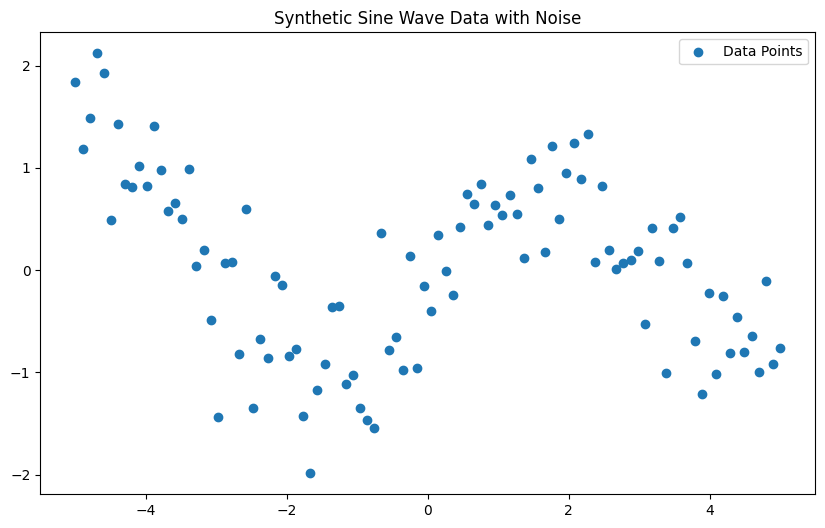

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve

# Generate some synthetic data
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = np.sin(X) + np.random.normal(0, 0.5, 100)
X = X[:, np.newaxis]

# Plot the data to see the underlying sine wave pattern
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Data Points')
plt.title('Synthetic Sine Wave Data with Noise')
plt.legend()
plt.show()

## Part 3: Modeling with Different ComplexitiesWe will use **Polynomial Regression** to control model complexity. A polynomial of degree 1 is a simple straight line (underfitting). A polynomial of degree 15 is a very complex, wiggly line (overfitting).**Your Task:** Train and visualize three models with different degrees (1, 4, and 15) to see underfitting, a good fit, and overfitting.

### Task 1: Train and Plot Models**Your Task:** For each degree (1, 4, 15), create a polynomial regression model, train it, and plot its predictions against the original data.

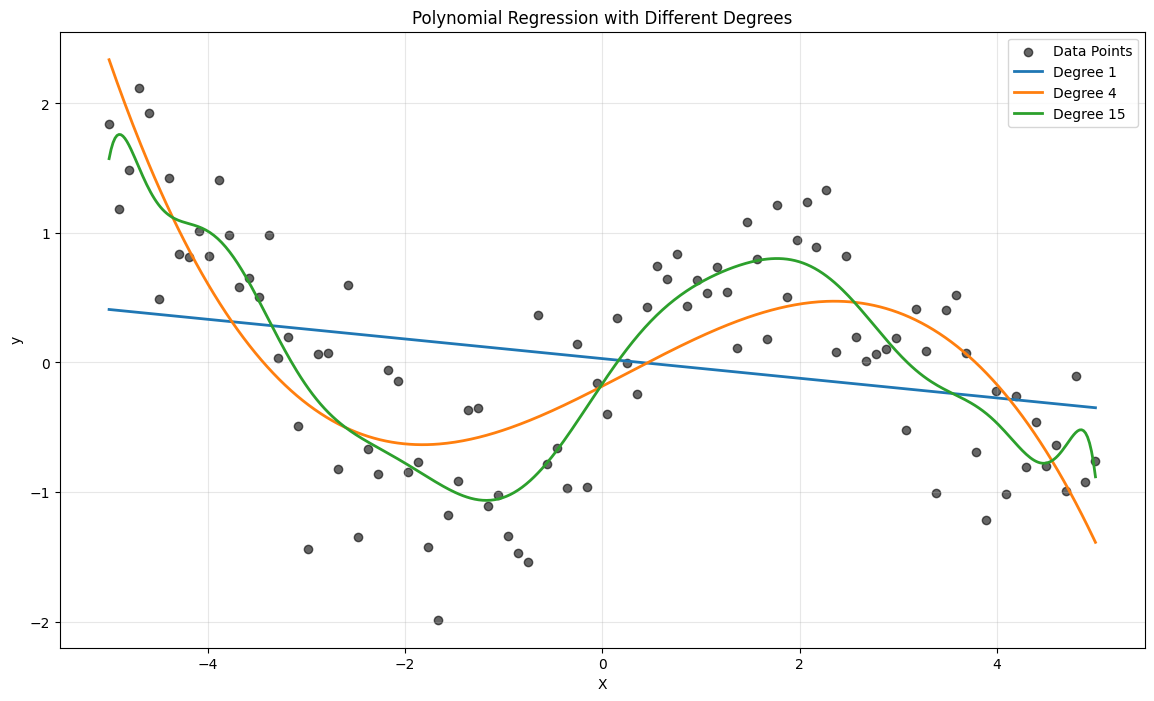

In [3]:
plt.figure(figsize=(14, 8))
plt.scatter(X, y, color='black', alpha=0.6, label='Data Points')

degrees = [1, 4, 15]
X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X, y)
    y_plot = model.predict(X_plot)

    plt.plot(X_plot, y_plot, linewidth=2, label=f'Degree {degree}')

plt.title('Polynomial Regression with Different Degrees')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In this lab, I built and explored polynomial regression models to understand underfitting, overfitting, and the bias‑variance tradeoff. I started by generating synthetic data that follows a sine wave with added random noise using NumPy, then visualized it with a scatter plot so I could see a realistic pattern with some randomness, similar to real-world data. After that, I created polynomial regression models with scikit‑learn using a pipeline of PolynomialFeatures and LinearRegression, and for degrees 1, 4, and 15 I fit the models and plotted their predictions on top of the original data to see how model complexity changes the fit. The degree‑1 model acted like a simple straight line that underfit the curved pattern, the degree‑15 model was flexible enough to follow the noise and overfit, and the intermediate degree provided a more balanced fit between the two extremes. I then set things up to analyze learning curves by defining a plot_learning_curve function that uses scikit‑learn’s learning_curve to compute training and cross‑validation scores for different training sizes and plot them, which will let me compare a clearly underfit model (degree 1) and an overfit model (degree 15) to see how their performance changes with more data and diagnose whether I’m dealing with high bias, high variance, or a good tradeoff.



## Part 4: Learning Curves**Concept:** A **learning curve** is a powerful tool to diagnose bias and variance. It plots the model's performance (e.g., accuracy or error) on both the **training set** and the **validation set** as a function of the number of training samples.*   **High Bias (Underfitting):** Both the training score and validation score will be low and will plateau quickly. The model is too simple to learn from more data.*   **High Variance (Overfitting):** There will be a large gap between the high training score and the low validation score. The model memorized the training data but can't generalize.*   **Just Right:** The training and validation scores will converge to a high value.

### Task 2: Plot Learning Curves**Your Task:** Use the `learning_curve` function from scikit-learn to plot the learning curves for the underfit (degree 1) and overfit (degree 15) models.

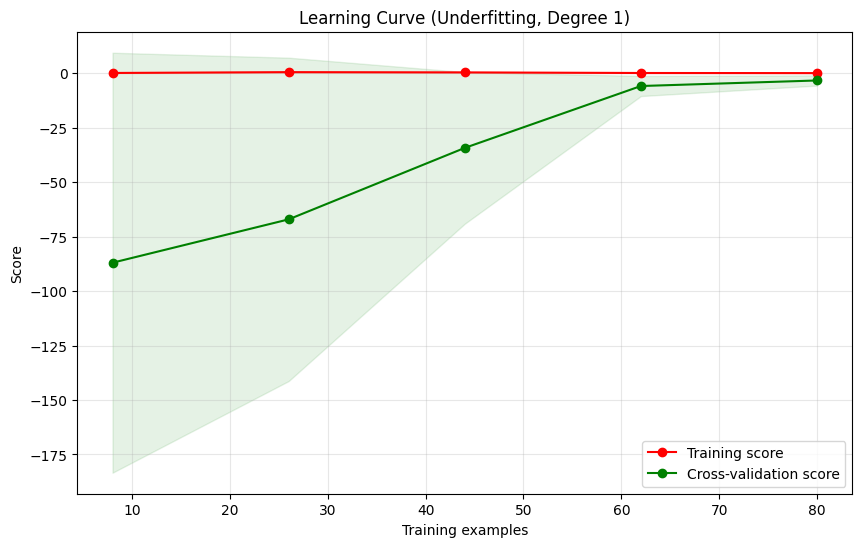

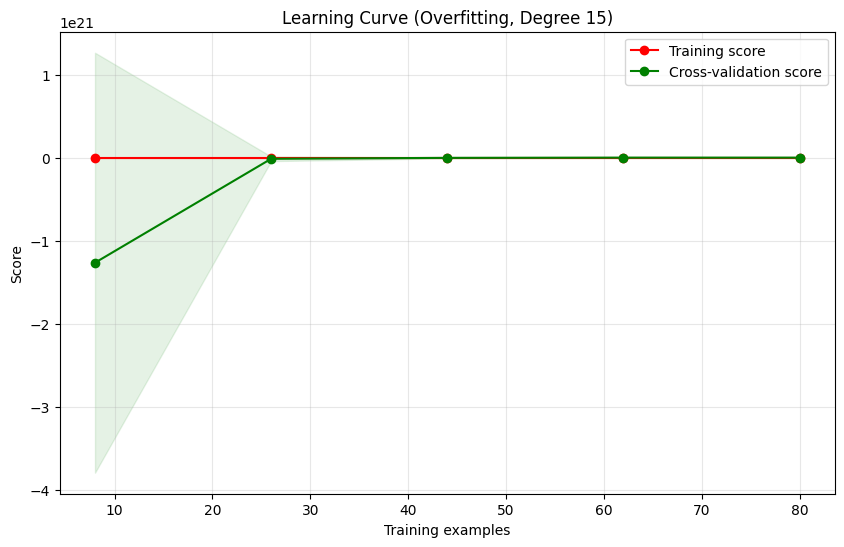

In [4]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5, n_jobs=None,
                        train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("Training examples")
    plt.ylabel("Score")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid(True, alpha=0.3)

    plt.fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="red"
    )
    plt.fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="green"
    )

    plt.plot(train_sizes, train_scores_mean, 'o-', color="red", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="green", label="Cross-validation score")

    plt.legend(loc="best")
    plt.show()


underfit_model = make_pipeline(PolynomialFeatures(1), LinearRegression())
overfit_model = make_pipeline(PolynomialFeatures(15), LinearRegression())

plot_learning_curve(
    underfit_model,
    "Learning Curve (Underfitting, Degree 1)",
    X, y, cv=5
)

plot_learning_curve(
    overfit_model,
    "Learning Curve (Overfitting, Degree 15)",
    X, y, cv=5
)

I focused on diagnosing bias and variance by using learning curves for my simple and complex polynomial models. I took the underfitting model (degree 1) and the overfitting model (degree 15) that I had already built and set them up to be passed into scikit‑learn’s learning_curve function along with my data, so I could see how their training and cross‑validation scores change as I give them more training examples. The idea was to generate plots where a high‑bias model should show both low training and validation scores that level off quickly, while a high‑variance model should show a big gap between a very high training score and a much lower validation score, helping me visually confirm which model is underfitting and which is overfitting.

## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **In the first plot of the three models, which model (degree 1, 4, or 15) is underfitting, which is overfitting, and which is a good fit? Explain your reasoning.**2.  **Looking at the learning curve for the underfitting model, what do you observe about the training and cross-validation scores?** What does this tell you?3.  **Looking at the learning curve for the overfitting model, what do you observe about the gap between the training and cross-validation scores?** What does this tell you?**[ENTER YOUR ANSWERS HERE]**

In the first plot, the degree 1 model is underfitting because it is just a straight line and clearly misses the curved sine-wave pattern in the data. The degree 15 model is overfitting because it wiggles a lot and follows the noise in the data too closely instead of capturing the general trend. The degree 4 model is a good fit because it captures the main shape of the sine wave without chasing every noisy fluctuation.

In the learning curve for the underfitting (degree 1) model, both the training and cross-validation scores are relatively low and they sit close together, often flattening out as the number of training examples increases. This tells me the model is too simple to learn the true pattern even when I give it more data, which is a classic high-bias situation.

In the learning curve for the overfitting (degree 15) model, the training score is very high while the cross-validation score is noticeably lower, and there is a clear gap between the two curves. This gap tells me the model is memorizing the training data but not generalizing well to new data, which is exactly what we expect from a high-variance, overfit model.

This tells me how well each model is balancing bias and variance and how well it’s likely to generalize to new data. When I see both the training and cross-validation scores low and close together, that tells me the model is too simple (high bias), so even with more data it can’t capture the true pattern. When I see a high training score but a much lower cross-validation score with a clear gap between the curves, that tells me the model is too complex (high variance), because it fits the training data extremely well but doesn’t perform as well on unseen data.